In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    rc('font', family='AppleGothic')
elif platform.system() == 'Linux': # Colab 등
    rc('font', family='NanumBarunGothic')

### dataset
---

In [2]:
from sklearn.datasets import load_wine, load_iris

wine = load_wine(as_frame=True)
iris = load_iris(as_frame=True)

TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(TITANIC_URL)

# TODO : 'Age' 결측치 처리
# 호칭별 평균/중앙값으로 채우기
# 호칭(Title) 추출
titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# 호칭별 나이 중앙값으로 결측치 채우기
titanic['Age'] = titanic['Age'].fillna(titanic.groupby('Title')['Age'].transform('median'))
# 혹시 남은 결측치는 전체 중앙값으로 보완
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

# TODO : 'Cabin' 결측치 처리
# 방 번호(Cabin)가 기록되지 않은 승객들은
# 주로 낮은 등급 객실(3등석)을 이용했을 확률이 높음.
# 즉, "기록이 없다"는 사실 자체가 생존율과 연관된 힌트
# 첫 글자만 추출하고, 결측치는 'N'으로 채우기
titanic['Cabin'] = titanic['Cabin'].fillna('N')
titanic['Deck'] = titanic['Cabin'].str[0]

# TODO : 'Embarked' 결측치 처리
# 1등석 요금 80달러 근처 승객들의 항구 최빈값 찾기
fare_filter = (titanic['Fare'] >= 70) & (titanic['Fare'] <= 90) & (titanic['Pclass'] == 1)
recommended_port = titanic[fare_filter]['Embarked'].mode()[0] # 결과로 'C'가 나옵니다.

# 2. 결측치 채우기
titanic['Embarked'] = titanic['Embarked'].fillna(recommended_port)


<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:12: SyntaxWarning: invalid escape sequence '\.'
C:\Users\금정산2-PC02\AppData\Local\Temp\ipykernel_1100\621528693.py:12: SyntaxWarning: invalid escape sequence '\.'
  titanic['Title'] = titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [3]:
tdf = titanic.copy()
tdf.drop(columns='Survived', inplace=True)
wdf = wine['data'].copy()
idf = iris['data'].copy()

### KMeans
---

In [7]:
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# 타이타닉에 사용할 컬럼 정의
numeric_features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
nominal_features = ['Sex', 'Embarked', 'Deck']

titanic_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
    ]
)

df_pipelines = {
    'iris': Pipeline(
        [
            # ('scaler', StandardScaler()),
            ('model', KMeans(n_clusters=3, random_state=42))
         ]
    ),
    'wine': Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', KMeans(n_clusters=3, random_state=42))
         ]
    ),
    'titanic': Pipeline(
        [
            ('preprocessor',titanic_preprocessor),
            ('model', KMeans(n_clusters=2, random_state=42))
        ]
    )
}


In [8]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score
from scipy.optimize import linear_sum_assignment

def evaluate_kmeans(name, X, y_true, pipeline):
    # KMeans 클러스터 예측
    cluster_pred = pipeline.fit_predict(X)

    # 실제 라벨 vs 클러스터 교차표
    cross_tab = pd.crosstab(
        pd.Series(y_true, name='Actual'),
        pd.Series(cluster_pred, name='Cluster')
    )

    # ARI, NMI는 클러스터 번호가 뒤섞여도 정상 평가 가능
    ari = adjusted_rand_score(y_true, cluster_pred)
    nmi = normalized_mutual_info_score(y_true, cluster_pred)

    # 사람이 보기 쉬운 accuracy 계산용:
    # 클러스터 번호를 실제 라벨에 가장 잘 맞게 재매핑
    cost_matrix = -cross_tab.values
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    mapping = {
        cross_tab.columns[col]: cross_tab.index[row]
        for row, col in zip(row_ind, col_ind)
    }

    mapped_pred = pd.Series(cluster_pred).map(mapping)

    acc = accuracy_score(y_true, mapped_pred)

    print(f'\n========== {name.upper()} ==========')
    print('[교차표: 실제 라벨 vs 클러스터]')
    display(cross_tab)

    print('[클러스터 → 실제 라벨 매핑]')
    print(mapping)

    print(f'ARI : {ari:.4f}')
    print(f'NMI : {nmi:.4f}')
    print(f'Mapped Accuracy : {acc:.4f}')

    return {
        'name': name,
        'cluster_pred': cluster_pred,
        'mapped_pred': mapped_pred,
        'cross_tab': cross_tab,
        'mapping': mapping,
        'ari': ari,
        'nmi': nmi,
        'accuracy': acc
    }

In [9]:
result = {}

result['iris'] = evaluate_kmeans(
    name = 'iris',
    X=idf,
    y_true=iris['target'],
    pipeline=df_pipelines['iris']
)

result['wine'] = evaluate_kmeans(
    name= 'wine',
    X=wdf,
    y_true=wine['target'],
    pipeline=df_pipelines['wine']
)

result['titanic'] = evaluate_kmeans(
    name='titanic',
    X=tdf,
    y_true=titanic['Survived'],
    pipeline=df_pipelines['titanic']
)


========== IRIS ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1,2
Actual,,,
0,0,50,0
1,3,0,47
2,36,0,14


[클러스터 → 실제 라벨 매핑]
{np.int32(1): np.int64(0), np.int32(2): np.int64(1), np.int32(0): np.int64(2)}
ARI : 0.7163
NMI : 0.7419
Mapped Accuracy : 0.8867

========== WINE ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1,2
Actual,,,
0,0,0,59
1,65,3,3
2,0,48,0


[클러스터 → 실제 라벨 매핑]
{np.int32(2): np.int64(0), np.int32(0): np.int64(1), np.int32(1): np.int64(2)}
ARI : 0.8975
NMI : 0.8759
Mapped Accuracy : 0.9663

========== TITANIC ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1
Actual,,
0,461,88
1,201,141


[클러스터 → 실제 라벨 매핑]
{np.int32(0): np.int64(0), np.int32(1): np.int64(1)}
ARI : 0.1114
NMI : 0.0624
Mapped Accuracy : 0.6756


#### Iris
---
- 붓꽃(Iris) 품종 분류 데이터셋
- 3가지 붓꽃 품종(Setosa, Versicolor, Virginica)
- 각각의 꽃받침(Sepal)과 꽃잎(Petal)의 길이 및 너비(단위: cm)를 측정한 150개의 샘플 데이터로 이루어져 있음.

- petal : 꽃잎
- sepal : 꽃받침

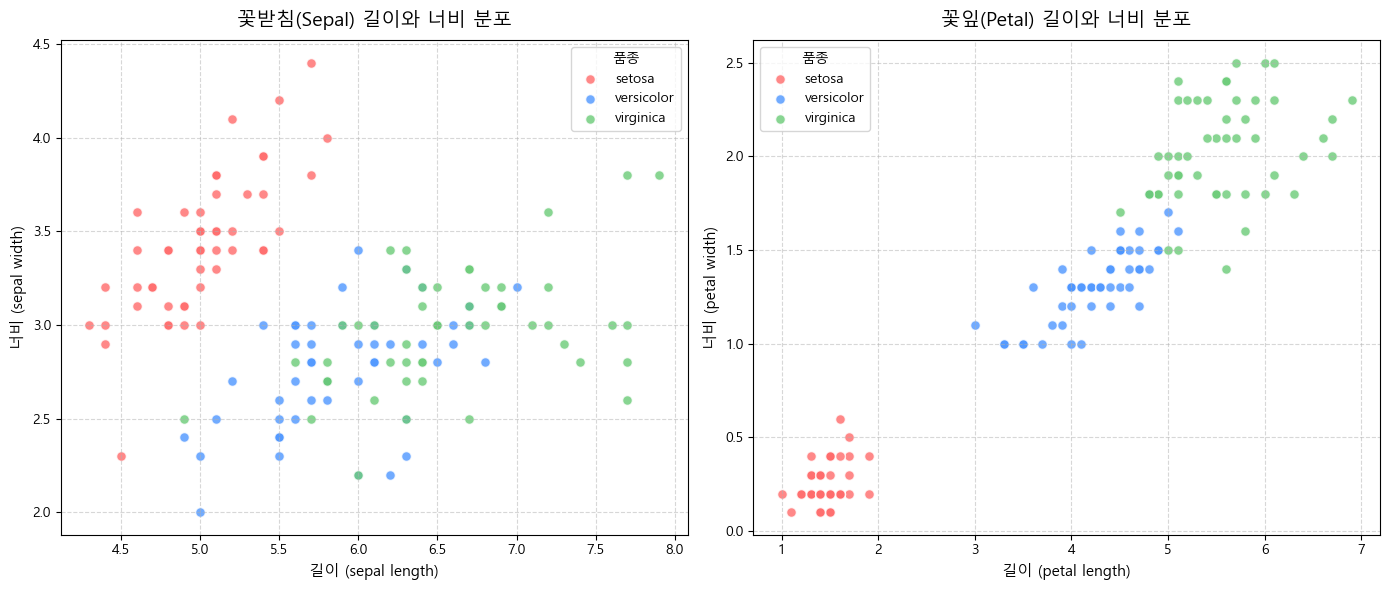

In [10]:
# 1. 데이터 로드 및 데이터프레임 변환
iris_dataset = load_iris(as_frame=True)
df = iris_dataset['data'].copy()
# 품종(target) 이름을 문자열로 매핑하여 추가
df['species'] = iris_dataset['target'].map(
    {i: name for i, name in enumerate(iris_dataset['target_names'])}
)

# 2. 그래프 스타일 및 한글 설정 (앞서 작성하신 한글 폰트 설정이 적용된 상태여야 합니다)
plt.figure(figsize=(14, 6))
colors = {'setosa': '#FF6B6B', 'versicolor': '#4D96FF', 'virginica': '#6BCB77'}

# 3. 첫 번째 서브플롯: 꽃받침(Sepal) 분포
plt.subplot(1, 2, 1)
for species, group in df.groupby('species'):
    plt.scatter(
        group['sepal length (cm)'],
        group['sepal width (cm)'],
        label=species,
        color=colors[species],
        alpha=0.8,
        edgecolors='w',
        s=50,
    )
plt.title('꽃받침(Sepal) 길이와 너비 분포', fontsize=14, pad=10)
plt.xlabel('길이 (sepal length)', fontsize=11)
plt.ylabel('너비 (sepal width)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='품종')

# 4. 두 번째 서브플롯: 꽃잎(Petal) 분포
plt.subplot(1, 2, 2)
for species, group in df.groupby('species'):
    plt.scatter(
        group['petal length (cm)'],
        group['petal width (cm)'],
        label=species,
        color=colors[species],
        alpha=0.8,
        edgecolors='w',
        s=50,
    )
plt.title('꽃잎(Petal) 길이와 너비 분포', fontsize=14, pad=10)
plt.xlabel('길이 (petal length)', fontsize=11)
plt.ylabel('너비 (petal width)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='품종')

plt.tight_layout()
plt.show()

★ 테스트 데이터셋 최종 정확도 (Accuracy): 96.67%

[상세 분류 레포트]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



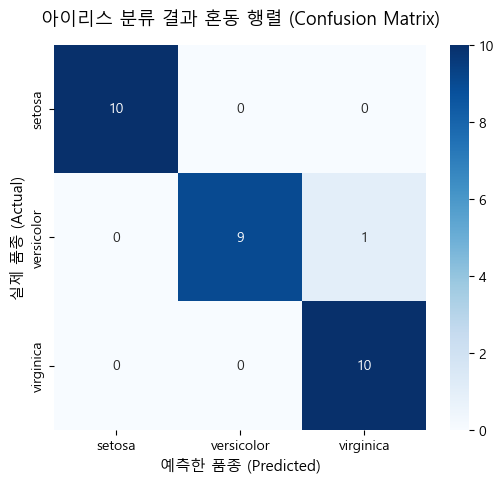

In [16]:
# SVM 학습
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

# 1. 데이터 로드 및 데이터 분할 (학습용 80%, 테스트용 20%)
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 파이프라인 구축 (스케일링 + SVM 분류기)
# SVM은 거리 기반 모델이므로 StandardScaler가 성능에 큰 영향을 줍니다.
best_model = Pipeline(
    [('scaler', StandardScaler()), ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))]
)

# 3. 모델 학습
best_model.fit(X_train, y_train)

# 4. 테스트 데이터로 예측 및 점수 검증
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print(f"★ 테스트 데이터셋 최종 정확도 (Accuracy): {accuracy * 100:.2f}%")
print("=" * 60)
print("\n[상세 분류 레포트]")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 5. 시각화: 혼동 행렬 (Confusion Matrix)로 어떤 타깃을 맞추고 틀렸는지 확인
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
)
plt.title('아이리스 분류 결과 혼동 행렬 (Confusion Matrix)', fontsize=13, pad=15)
plt.xlabel('예측한 품종 (Predicted)', fontsize=11)
plt.ylabel('실제 품종 (Actual)', fontsize=11)
plt.show()

- 아이리스 데이터셋의 경우 본래 데이터 양이 작고 클래스 간 경계가 비교적 명확한 데이터.

In [ ]:
result['iris'] = evaluate_kmeans(
    name = 'iris',
    X=idf,
    y_true=iris['target'],
    pipeline=df_pipelines['iris']
)


========== IRIS ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1,2
Actual,,,
0,0,50,0
1,3,0,47
2,36,0,14


[클러스터 → 실제 라벨 매핑]
{np.int32(1): np.int64(0), np.int32(2): np.int64(1), np.int32(0): np.int64(2)}
ARI : 0.7163
NMI : 0.7419
Mapped Accuracy : 0.8867


- 행 Actual = 실제 라벨
- 열 Cluster = KMeans가 붙인 클러스터 번호
- 숫자 = 해당되는 데이터 개수

- ARI = Adjusted Rand Index
    - 실제 라벨과 클러스터 결과가 “같은 애들끼리 묶였는지”를 보는 점수
- KMeans가 실제 iris 품종 구조를 상당히 잘 따라갔다.
---
- NMI = Normalized Mutual Information
    - 클러스터 결과를 알면 실제 라벨 정보를 얼마나 알 수 있는가? 클러스터별 데이터 순수도?
- 클러스터 결과가 실제 품종 정보를 꽤 많이 담고 있다.

In [13]:
iris_df = iris['data'].copy()
iris_df['target'] = iris['target']

iris_df.groupby('target').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


■ 주성분별 원본 변수 기여도(고유벡터) 값:
             sepal length (cm)  sepal width (cm)  petal length (cm)  \
주성분 1 (PC1)              0.521            -0.269              0.580   
주성분 2 (PC2)              0.377             0.923              0.024   

             petal width (cm)  
주성분 1 (PC1)             0.565  
주성분 2 (PC2)             0.067  




d:\study-flat\ml5\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
d:\study-flat\ml5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


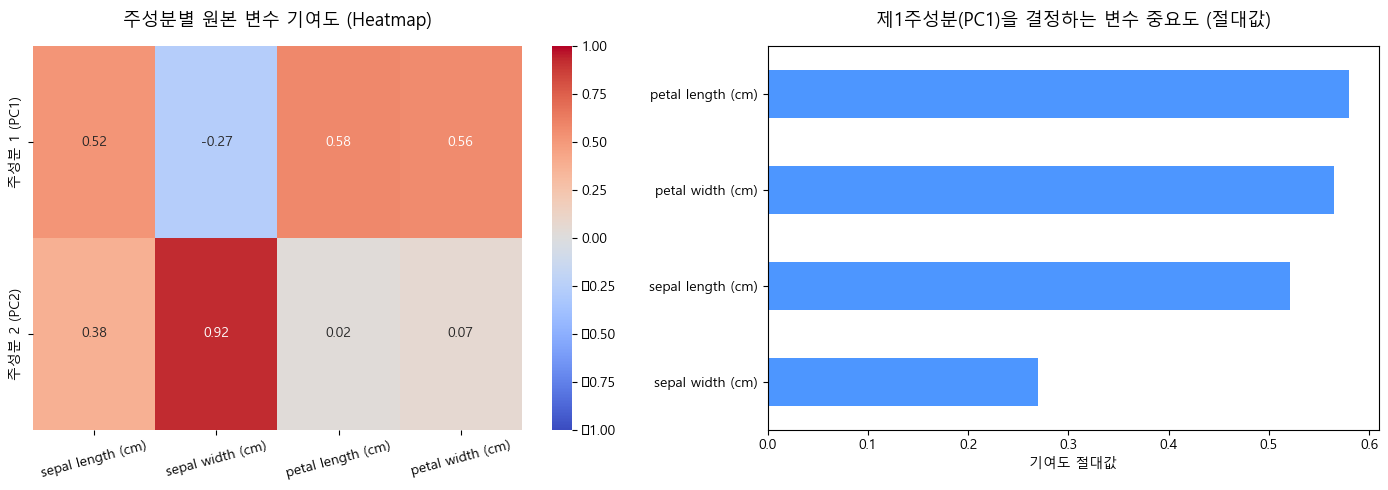

제1주성분(PC1) 설명력: 72.96%
제2주성분(PC2) 설명력: 22.85%


In [ ]:
from sklearn.decomposition import PCA
# 1. 데이터 로드 및 스케일링 (PCA 전 표준화는 필수입니다)
iris_dataset = load_iris(as_frame=True)
X = iris_dataset['data']
feature_names = iris_dataset['feature_names']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA 수행 (주성분 2개 추출)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. 주성분별 원본 컬럼의 기여도(로딩 벡터) 추출
# pca.components_ 구조: (n_components, n_features)
components_df = pd.DataFrame(
    pca.components_, 
    columns=feature_names, 
    index=['주성분 1 (PC1)', '주성분 2 (PC2)']
)

print("■ 주성분별 원본 변수 기여도(고유벡터) 값:")
print(components_df.round(3))
print("\n" + "="*50 + "\n")

# 4. 시각화: 히트맵과 바차트로 중요도 확인하기
plt.figure(figsize=(14, 5))

# [왼쪽] 히트맵으로 기여도 시각화
plt.subplot(1, 2, 1)
sns.heatmap(components_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True, fmt=".2f")
plt.title('주성분별 원본 변수 기여도 (Heatmap)', fontsize=13, pad=15)
plt.xticks(rotation=15)

# [오른쪽] 가장 분산 설명력이 높은 '주성분 1'을 구성하는 변수 중요도 (절대값 기준)
plt.subplot(1, 2, 2)
pc1_importance = components_df.loc['주성분 1 (PC1)'].abs().sort_values(ascending=True)
pc1_importance.plot(kind='barh', color='#4D96FF')
plt.title('제1주성분(PC1)을 결정하는 변수 중요도 (절대값)', fontsize=13, pad=15)
plt.xlabel('기여도 절대값')

plt.tight_layout()
plt.show()

# 5. 각 주성분이 전체 분산을 얼마나 설명하는지 출력
print(f"제1주성분(PC1) 설명력: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"제2주성분(PC2) 설명력: {pca.explained_variance_ratio_[1]*100:.2f}%")

- 스케일링 전 결과가 스케일링 후보다 더 잘나오는 이유?
     - 실제 품종 구분에 훨씬 중요한 건 보통 petal length, petal width
     - KMeans는 거리를 보고 군집을 나누니까, 스케일링 전에는 품종 구분에 유리한 petal 계열 피처가 더 강하게 반영되어 분류됨.
     - 스케일링 후에는 sepal 계열 특성까지 동일한 비중을 갖게 되어 군집 성능이 오히려 저하될 수 있다.
     - 따라서 스케일링이 항상 성능을 높이는 것은 아니며, 특성의 단위와 중요도를 고려해서 적용해야함.
---

### 와인데이터셋
---

In [18]:
# 와인 데이터셋: 스케일링 전후 KMeans 비교

wine_raw_pipeline = Pipeline(
    [
        ('model', KMeans(n_clusters=3, random_state=42))
    ]
)

wine_scaled_pipeline = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', KMeans(n_clusters=3, random_state=42))
    ]
)

raw_result = evaluate_kmeans(
    name='wine_raw',
    X=wdf,
    y_true=wine['target'],
    pipeline=wine_raw_pipeline
)

scaled_result = evaluate_kmeans(
    name='wine_scaled',
    X=wdf,
    y_true=wine['target'],
    pipeline=wine_scaled_pipeline
)

wine_compare_df = pd.DataFrame({
    '스케일링 전': {
        'ARI': raw_result['ari'],
        'NMI': raw_result['nmi'],
        'Mapped Accuracy': raw_result['accuracy']
    },
    '스케일링 후': {
        'ARI': scaled_result['ari'],
        'NMI': scaled_result['nmi'],
        'Mapped Accuracy': scaled_result['accuracy']
    }
}).T

wine_compare_df


========== WINE_RAW ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1,2
Actual,,,
0,1,31,27
1,64,7,0
2,37,11,0


[클러스터 → 실제 라벨 매핑]
{np.int32(2): np.int64(0), np.int32(0): np.int64(1), np.int32(1): np.int64(2)}
ARI : 0.3518
NMI : 0.4233
Mapped Accuracy : 0.5730

========== WINE_SCALED ==========
[교차표: 실제 라벨 vs 클러스터]


Cluster,0,1,2
Actual,,,
0,0,0,59
1,65,3,3
2,0,48,0


[클러스터 → 실제 라벨 매핑]
{np.int32(2): np.int64(0), np.int32(0): np.int64(1), np.int32(1): np.int64(2)}
ARI : 0.8975
NMI : 0.8759
Mapped Accuracy : 0.9663


,ARI,NMI,Mapped Accuracy
스케일링 전,0.351772,0.423309,0.573034
스케일링 후,0.897495,0.875894,0.966292


d:\study-flat\ml5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


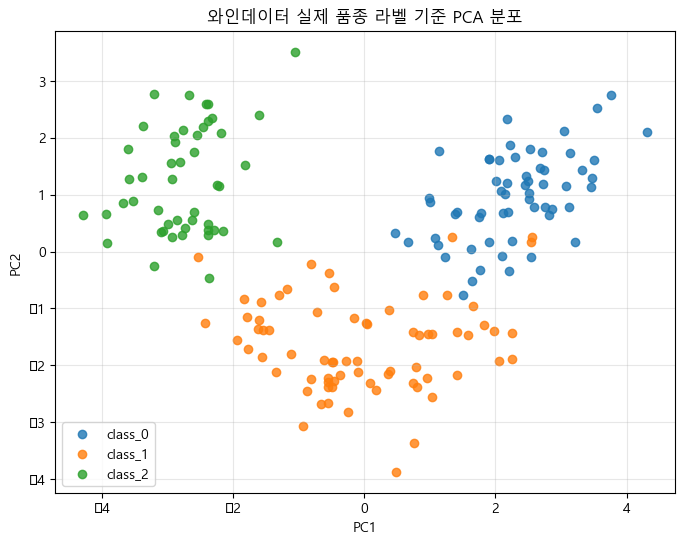

In [19]:
# 와인 데이터
X_wine = wine['data'].copy()
y_wine = wine['target'].copy()
target_names = wine['target_names']

# 스케일링
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_wine_pca = pca.fit_transform(X_wine_scaled)

# 데이터프레임 생성
wine_pca_df = pd.DataFrame(
    X_wine_pca,
    columns=['PC1', 'PC2']
)

wine_pca_df['target'] = y_wine
wine_pca_df['target_name'] = wine_pca_df['target'].map(
    lambda x: target_names[x]
)

# 시각화
plt.figure(figsize=(8, 6))

for target in sorted(wine_pca_df['target'].unique()):
    data = wine_pca_df[wine_pca_df['target'] == target]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        label=target_names[target],
        alpha=0.8
    )

plt.title('와인데이터 실제 품종 라벨 기준 PCA 분포')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
print('PC1 설명력:', pca.explained_variance_ratio_[0])
print('PC2 설명력:', pca.explained_variance_ratio_[1])
print('누적 설명력:', pca.explained_variance_ratio_.sum())

PC1 설명력: 0.3619884809992633
PC2 설명력: 0.19207490257008947
누적 설명력: 0.5540633835693527


C:\Users\금정산2-PC02\AppData\Local\Temp\ipykernel_1100\2913023530.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
d:\study-flat\ml5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


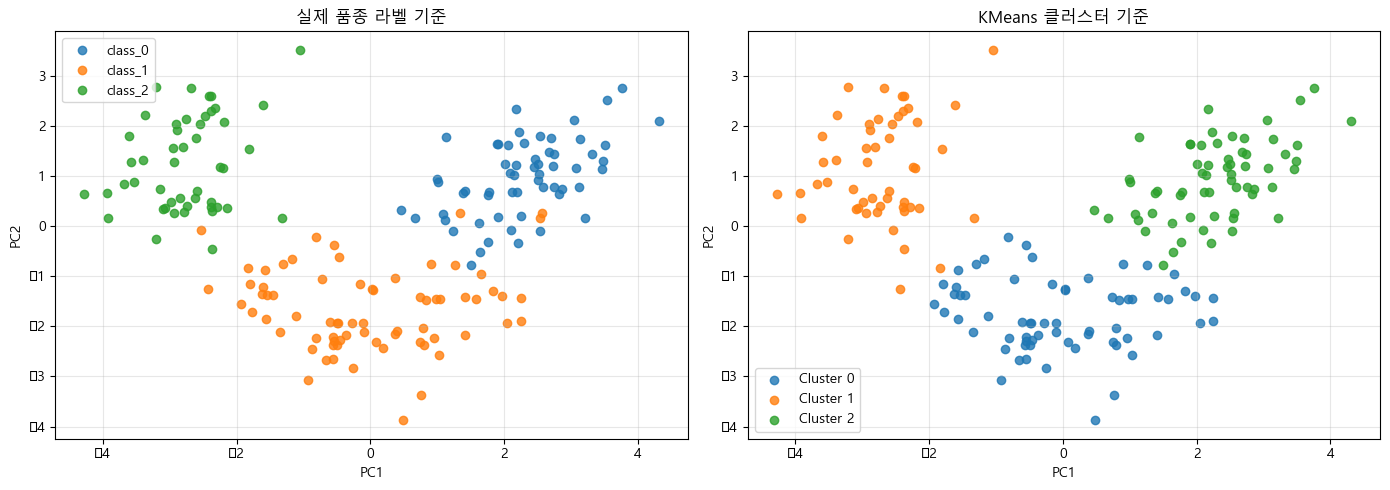

In [21]:
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
wine_cluster = kmeans.fit_predict(X_wine_scaled)

wine_pca_df['cluster'] = wine_cluster

plt.figure(figsize=(14, 5))

# 실제 라벨 기준
plt.subplot(1, 2, 1)

for target in sorted(wine_pca_df['target'].unique()):
    data = wine_pca_df[wine_pca_df['target'] == target]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        label=target_names[target],
        alpha=0.8
    )

plt.title('실제 품종 라벨 기준')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)

# KMeans 클러스터 기준
plt.subplot(1, 2, 2)

for cluster in sorted(wine_pca_df['cluster'].unique()):
    data = wine_pca_df[wine_pca_df['cluster'] == cluster]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.8
    )

plt.title('KMeans 클러스터 기준')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- load_wine은 애초에 깨끗한 데이터셋( 3개 품종 분류 ) : 학습용 예제 데이터로 결측치, 이상치, 노이즈 별로 없음
- feature의 화학 성분들이 품종별로 잘 갈라지는 편이라 선형 모델도 잘 맞는 편
- 데이터 크기가 작음
- test_train split 기준 - 45 / 133개 : 실전도 완벽하다 보다는 테스트에서 다 맞출 수 있었다로 해석

- 특히 선형 모델의 결과가 트리 모델보다 더 잘 나온 것은 이 데이터는 복잡한 비선형 모델이 아니어도 충분히 잘 분리된다고 볼 수 있음.

- 교차표에서도 비교적 명확히 분리되는 것을 볼 수 있는데 이는 품종별 화학적 차이가 뚜렷하게 반영하고 있기 때문.
- 또한 데이터셋 특성상 스케일링을 통한 표준화가 중요한데 이를 통해 특정 수치 범위가 큰 변수만 거리 계산을 지배하는 것을 방지하고, 여러 화학적 특성이 균형 있게 군집 형성에 반영되어 실제 라벨과 유사한 군집 구조가 나타났다고 볼 수 있음.

- 선형 모델이 잘 맞는 데이터가 KMeans도 좋을까?
    - 선형 모델이 잘 맞는 데이터가 KMeans에도 유리할 수는 있지만, 두 알고리즘의 기준은 다르다.
    - 선형 모델은 분류 경계선을 학습하고, KMeans는 거리 기반으로 중심점에 가까운 데이터를 묶는다. 따라서 KMeans에 유리한 데이터는 선형적인 데이터라기보다, 각 클래스가 특성 공간에서 서로 떨어진 군집 형태를 이루는 데이터라고 표현하는 것이 더 정확하다.
---

### 타이타닉
---

- 타이타닉 KMeans 분류에 실패 후 랜덤 포레스트를 시도해봤다.

In [22]:
from sklearn.ensemble import RandomForestClassifier
# 사용할 피처
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'Title',
    'Deck'
]

X = titanic[features].copy()
y = titanic['Survived'].copy()

# 범주형 / 숫자형 피처 분리
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck']

# 전처리
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 랜덤 포레스트 파이프라인
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            random_state=42
        ))
    ]
)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 학습
rf_pipeline.fit(X_train, y_train)

# 예측
y_pred = rf_pipeline.predict(X_test)

# 점수 확인
train_score = rf_pipeline.score(X_train, y_train)
test_score = rf_pipeline.score(X_test, y_test)

print(f'Train Accuracy : {train_score:.4f}')
print(f'Test Accuracy  : {test_score:.4f}')

print('\nClassification Report')
print(classification_report(y_test, y_pred))

Train Accuracy : 0.8455
Test Accuracy  : 0.7989

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



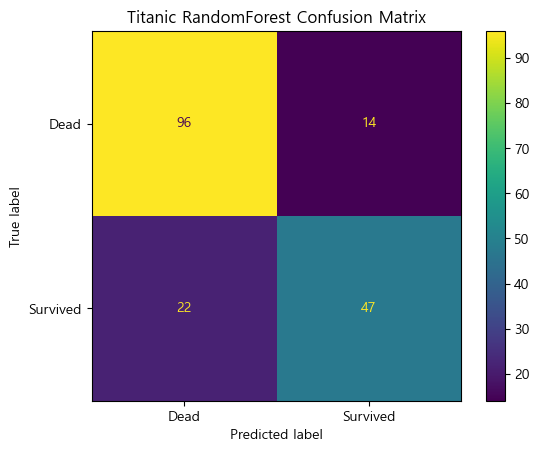

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Dead', 'Survived']
)

disp.plot()
plt.title('Titanic RandomForest Confusion Matrix')
plt.show()

ROC AUC : 0.8460


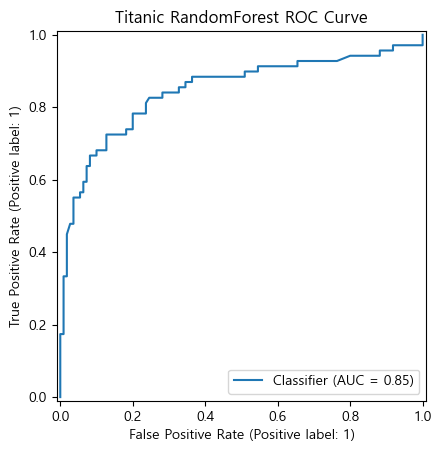

In [24]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = rf_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f'ROC AUC : {auc:.4f}')

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('Titanic RandomForest ROC Curve')
plt.show()

#### 영향을 준 피처

In [25]:
# 전처리 후 피처 이름 가져오기
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 중요도
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance_df.head(15)

,feature,importance
19,cat__Title_Mr,0.180649
6,cat__Sex_male,0.162245
5,cat__Sex_female,0.150594
4,num__Fare,0.091376
0,num__Pclass,0.081682
1,num__Age,0.058820
31,cat__Deck_N,0.054505
20,cat__Title_Mrs,0.041874
17,cat__Title_Miss,0.041183
2,num__SibSp,0.031672


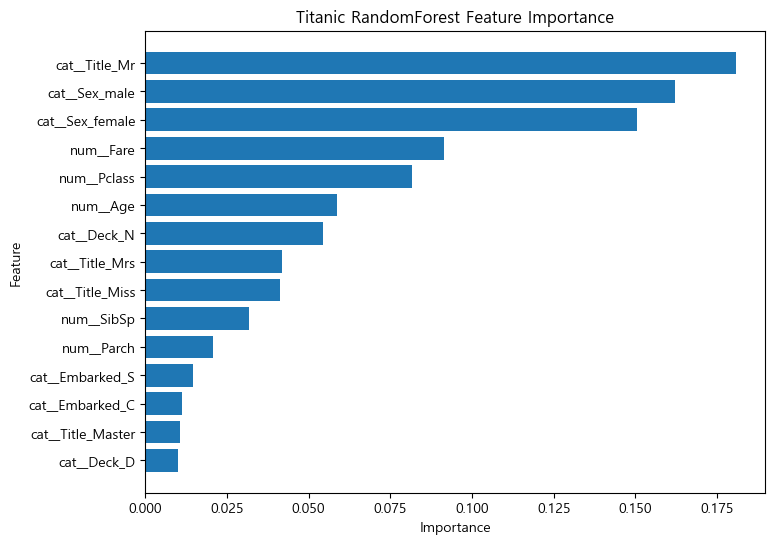

In [26]:
top_n = 15

plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df.head(top_n)['feature'][::-1],
    feature_importance_df.head(top_n)['importance'][::-1]
)

plt.title('Titanic RandomForest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

d:\study-flat\ml5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


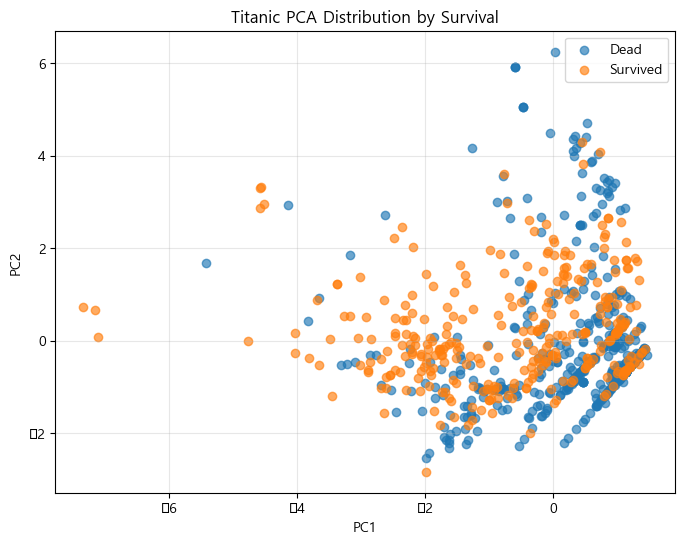

In [27]:
# 사용할 피처
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'Title',
    'Deck'
]

X_titanic = titanic[features].copy()
y_titanic = titanic['Survived'].copy()

# 숫자형 / 범주형 피처
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck']

# PCA용 전처리
pca_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 전처리 적용
X_titanic_processed = pca_preprocessor.fit_transform(X_titanic)

# PCA 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_titanic_pca = pca.fit_transform(X_titanic_processed)

# PCA 결과 데이터프레임
titanic_pca_df = pd.DataFrame(
    X_titanic_pca,
    columns=['PC1', 'PC2']
)

titanic_pca_df['Survived'] = y_titanic.values
titanic_pca_df['Survived_Label'] = titanic_pca_df['Survived'].map({
    0: 'Dead',
    1: 'Survived'
})

# 시각화
plt.figure(figsize=(8, 6))

for label in sorted(titanic_pca_df['Survived'].unique()):
    data = titanic_pca_df[titanic_pca_df['Survived'] == label]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        alpha=0.65,
        label='Survived' if label == 1 else 'Dead'
    )

plt.title('Titanic PCA Distribution by Survival')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
print('PC1 설명력:', pca.explained_variance_ratio_[0])
print('PC2 설명력:', pca.explained_variance_ratio_[1])
print('누적 설명력:', pca.explained_variance_ratio_.sum())

PC1 설명력: 0.27081811926426685
PC2 설명력: 0.2569838726228078
누적 설명력: 0.5278019918870747


C:\Users\금정산2-PC02\AppData\Local\Temp\ipykernel_1100\3234438181.py:44: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
d:\study-flat\ml5\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


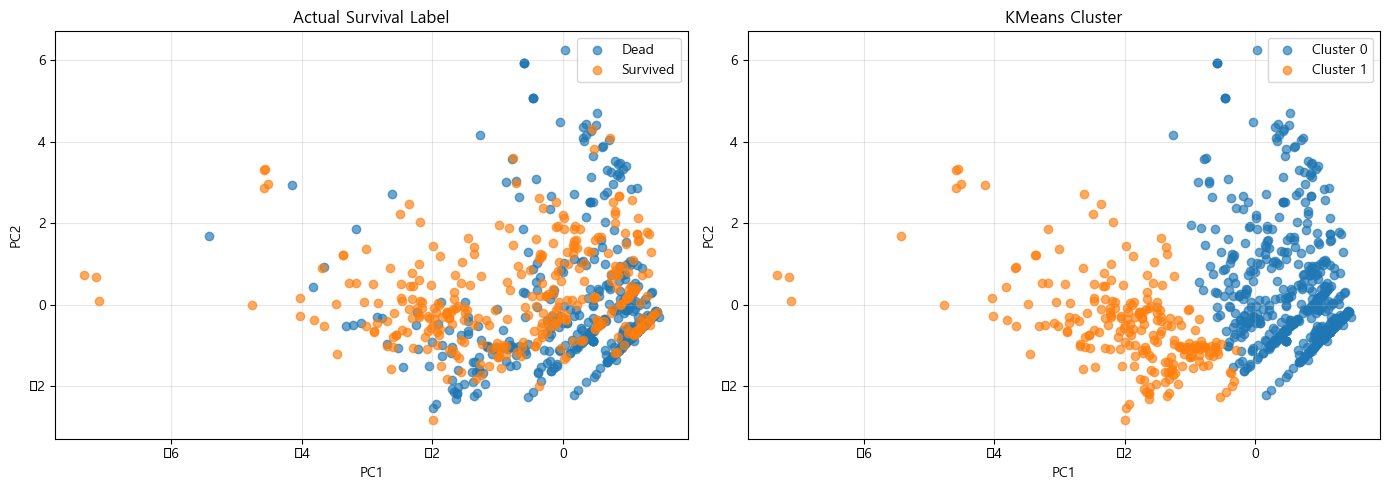

In [29]:
kmeans = KMeans(n_clusters=2, random_state=42)
titanic_cluster = kmeans.fit_predict(X_titanic_processed)

titanic_pca_df['Cluster'] = titanic_cluster

plt.figure(figsize=(14, 5))

# 실제 생존 여부
plt.subplot(1, 2, 1)

for label in sorted(titanic_pca_df['Survived'].unique()):
    data = titanic_pca_df[titanic_pca_df['Survived'] == label]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        alpha=0.65,
        label='Survived' if label == 1 else 'Dead'
    )

plt.title('Actual Survival Label')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)

# KMeans 클러스터
plt.subplot(1, 2, 2)

for cluster in sorted(titanic_pca_df['Cluster'].unique()):
    data = titanic_pca_df[titanic_pca_df['Cluster'] == cluster]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        alpha=0.65,
        label=f'Cluster {cluster}'
    )

plt.title('KMeans Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
- Titanic 데이터셋의 생존 여부는 와인이나 아이리스 데이터셋처럼 특성 공간에서 자연스럽게 구분되는 구조를 보이지 않았다.
- 생존 여부는 성별, 객실 등급, 나이, 요금, 가족 동승 여부 등 여러 피처가 작용한 결과이며,
- 그 외 잘생김 같은 데이터에 기록되지 않은 요인이 복합적으로 작용한 결과이다.
- 따라서 KMeans와 같은 비지도학습 알고리즘은 생존 여부를 명확하게 분리하기 어렵다.

    - 이처럼 타이타닉 데이터같은 사회 현상 데이터에서는 관측된 피처만으로 결과를 완전히 설명하기 어렵고,
    - 변수간의 복잡한 상호 작용과 데이터에 포함되지 않은 요인까지 고려해야 한다고 볼 수 있다.